<center><h1>Keehan_Alyssa_HW2</h1></center>
<br>
<br>

**Name:** Alyssa Keehan 

**GitHub Username:** akeehan56

**GitHub Links:** [Class Repo](https://github.com/akeehan56/DSCI552) | [HW2](https://github.com/akeehan56/DSCI552/tree/main/HW2)

**Email:** akeehan@usc.edu  

**USC ID:** 3429542433

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from statsmodels.tools.eval_measures import mse
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# ! pip install pandas openpyxl
# ! pip install pandas statsmodels


Get the Cycle Power Plant Data Set

In [2]:
df = pd.read_excel("../Data/CCPP/Folds5x2_pp.xlsx")
print(df.head())


      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
df.shape

(9568, 5)

**Answer**:

There are **5** **columns** and **9,568** **rows** in this dataset.

The columns represent the 5 different features related to the Combined Cycle Power Plant (CCPP) over the years of 2006-2011. The rows are the hourly averages of these features from that 6-year window. The independent features include Temperature (AT), Ambient Pressure (AP), Relative Humidity (RH), and Exhaust Vacuum (V), which are all used to predict the dependent variable, the net hourly electrical energy output (PE) of the plant.

#### ii. pairwise scatterplots of all the variables

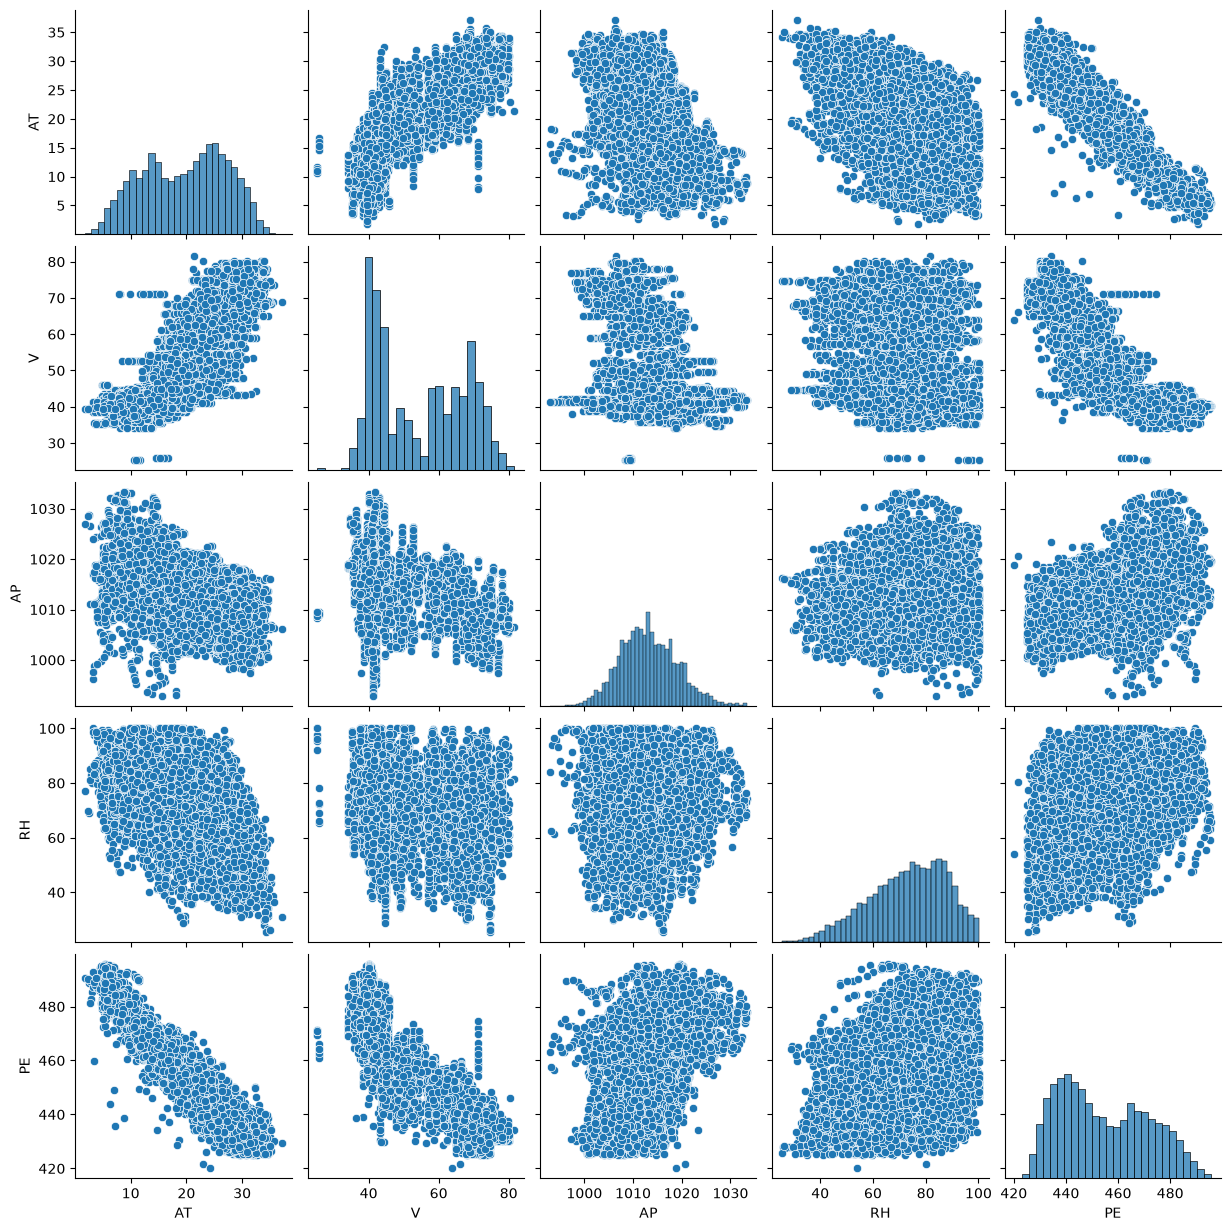

In [4]:

sns.pairplot(
    df,
    vars=df.columns,
    diag_kind="hist"
)

plt.show()

**Answer:**

The two variables with the strongest linear relationship are Average Temperature (AT) and Net Hourly Electrical Energy Output of the Plant (PE), which seems to show a negative relationship. This indicates that as Average Temperature increases, the net hourly energy output decreases.

The next strongest relationship we're seeing is Exhaust Vacuum (V) vs. energy output (PE), also showing a slight negative relationship between the two variables.

All other variable combinations show little to no linear relationship, with even distribution of data points across the whole graph, indicating that an increase/decrease in one of the fields doesn't necessarily correlate with an increase/decrease in the other.

In terms of normal distribution for each of the variables, average temperature (AT), Exhaust Vacuum (V), and our dependent variable, net hourly electrical energy output (PE), all show a bimodal distribution. Ambient Pressure (AP) shows a normal distribution, and Relative Humidity (RH) shows a left-skewed distribution.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
summary = df.describe()
summary.loc['range'] = summary.loc['max'] - summary.loc['min']
summary.loc['IQR'] = summary.loc['75%'] - summary.loc['25%']
final_metrics = summary.loc[['mean', '50%', 'range', '25%', '75%', 'IQR']].round(2)
final_metrics 

,AT,V,AP,RH,PE
mean,19.65,54.31,1013.26,73.31,454.37
50%,20.34,52.08,1012.94,74.97,451.55
range,35.30,56.20,40.41,74.60,75.50
25%,13.51,41.74,1009.10,63.33,439.75
75%,25.72,66.54,1017.26,84.83,468.43
IQR,12.21,24.80,8.16,21.50,28.68


### (c) Simple Linear Regression

***AI Notes***

I used AI to help structure the code with statsmodels since I'm unfamiliar with this package. I'm used to leveraging scikit-learn for ML methods/functions.

The prompt I used was "I'm supposed to use statsmodels to fit a simple linear and multiple regression model to my data. What packages do I need and what is the starter code to set that up?"

The following pieces of code were built from the starter code received as a response from chat.

In [6]:
independent_variables = df.columns.drop("PE")

results = []

for variable in independent_variables:

    simple_model = smf.ols(
        formula=f"PE ~ {variable}",
        data=df
    ).fit()

    confidence_intervals = simple_model.conf_int()

    results.append({
        "Predictor": variable,
        "R-squared": simple_model.rsquared,
        "Intercept": simple_model.params["Intercept"],
        "Coefficient": simple_model.params[variable],
        "Coefficient Std. Error": simple_model.bse[variable],
        "p-value": simple_model.pvalues[variable],
        "95% CI Lower": confidence_intervals.loc[variable, 0],
        "95% CI Upper": confidence_intervals.loc[variable, 1],
    })

simple_regression_summary = pd.DataFrame(results)

simple_regression_summary

,Predictor,R-squared,Intercept,Coefficient,Coefficient Std. Error,p-value,95% CI Lower,95% CI Upper
0,AT,0.898948,497.034120,-2.171320,0.007443,0.0,-2.185910,-2.156730
1,V,0.756518,517.801526,-1.168135,0.006776,0.0,-1.181417,-1.154853
2,AP,0.268769,-1055.260989,1.489872,0.025126,0.0,1.440620,1.539124
3,RH,0.151939,420.961766,0.455650,0.011006,0.0,0.434075,0.477225


**Answer:**
* All four predictors produce a ($p$ value < 0.001) and the confidence intervals do not cross 0, so we can reject the null hypothesis that $H_0: \beta_j = 0$ for all predictors in their individual simple linear regression equations. This could be the result of having a large sample size of 9.6K, which reduces standard errors.
* As mentioned in an earlier question, the strongest linear relationship is between Average Temperature and Energy Output, with an $R^2$ of 0.899, indicating that Average Temperature explains 89.9% of the variability in Energy Output.
* Exhaust Vacuum also produced a high $R^2$ of 0.757, indicating that it explains 75.7% of the variability in Energy Output.
* Both Ambient Pressure and Relative Humidity produced low $R^2$ values (< 50%), which indicate relatively weak linear relationships with the outcome variable.

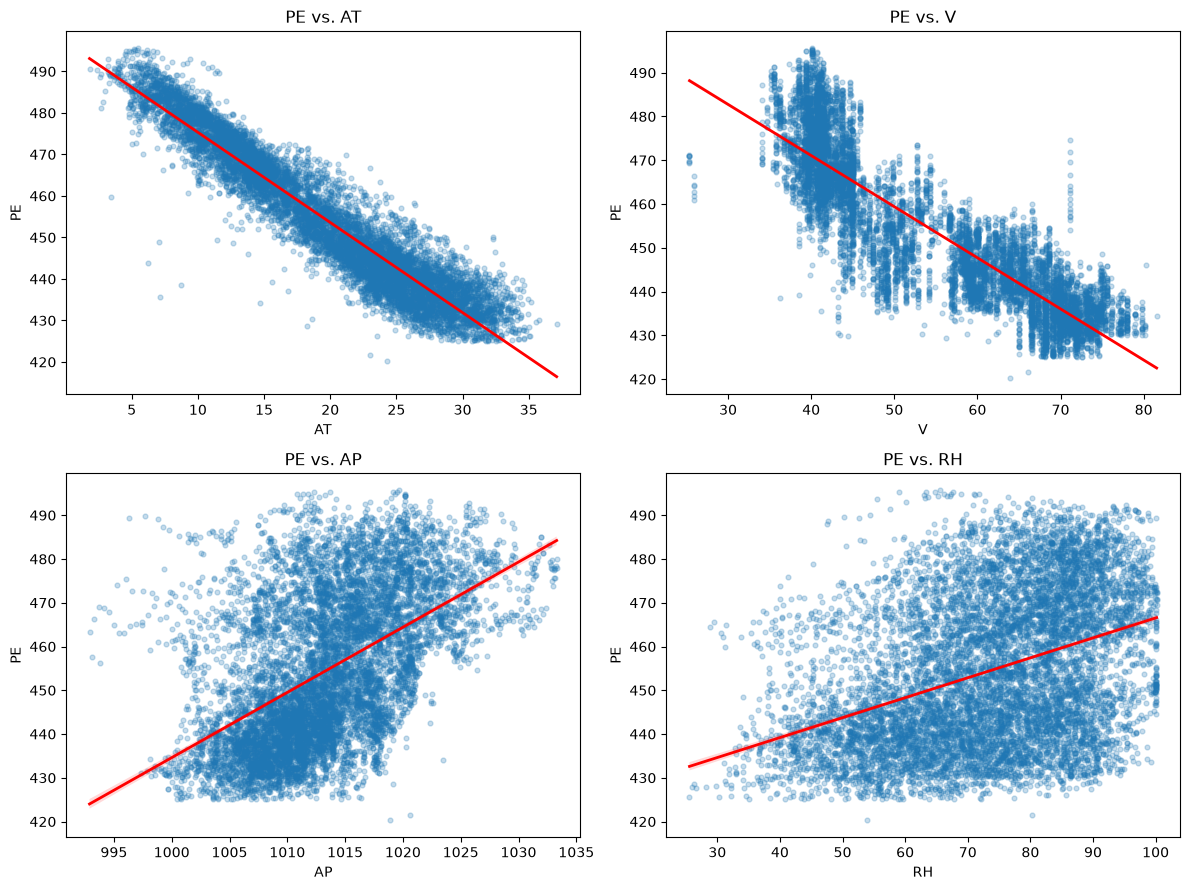

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for predictor, ax in zip(independent_variables, axes.flatten()):
    sns.regplot(
        data=df,
        x=predictor,
        y="PE",
        scatter_kws={"alpha": 0.25, "s": 12},
        line_kws={"color": "red", "linewidth": 2},
        ax=ax
    )

    ax.set_title(f"PE vs. {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

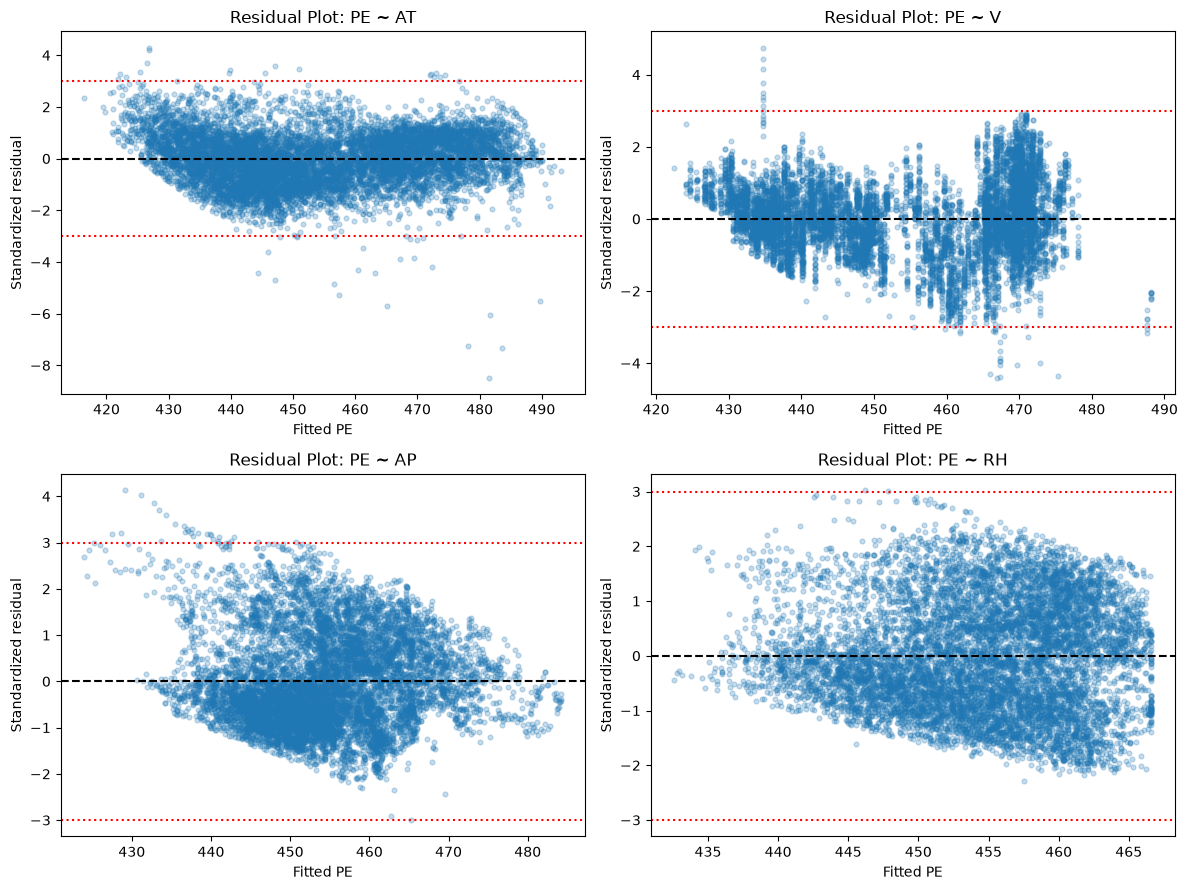

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for predictor, ax in zip(independent_variables, axes.flatten()):
    model = smf.ols(f"PE ~ {predictor}", data=df).fit()
    influence = model.get_influence()
    standardized_residuals = influence.resid_studentized_internal

    ax.scatter(
        model.fittedvalues,
        standardized_residuals,
        alpha=0.25,
        s=12
    )

    ax.axhline(0, color="black", linestyle="--")
    ax.axhline(3, color="red", linestyle=":")
    ax.axhline(-3, color="red", linestyle=":")
    ax.set_title(f"Residual Plot: PE ~ {predictor}")
    ax.set_xlabel("Fitted PE")
    ax.set_ylabel("Standardized residual")

plt.tight_layout()
plt.show()

**Answer:**
* Above are standardized residual plots, which are intended to point out any observations that could be considered outliers (> 3 standard deviations).
* Interestingly enough, there are more outliers for the predictors with a stronger relationship with Energy Output, which may be because of small residual variation, as points that depart from a tighter, stronger model stand out more clearly. This does not mean that stronger relationships inherently produce more outliers, and we should not remove them.
* Because the overall range of PE still happens to be around 420-490, there's not enough clear indication of a mistake in data entry that would influence us to remove any outliers. Unless further investigation shows that they are erroneous or highly influential, they should remain in the dataset.

### (d) Multiple Regression

In [9]:
multiple_model = smf.ols(
    formula="PE ~ AT + V + AP + RH",
    data=df
).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:59:13   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

**Answer:**

The fitted multiple linear regression equation is:
$$
\widehat{PE}
= 454.6093 - 1.9775(AT) - 0.2339(V) + 0.0621(AP) - 0.1581(RH)
$$

The model has an $R^2$ of 0.929, meaning that the predictors collectively account for 92.9% of the variability in PE. The overall model is statistically significant ($p<0.001$).

Holding the other predictors constant, AT, V, and RH have negative associations with PE, while AP has a positive association. All predictors have p-values below 0.001 and confidence intervals that do not contain zero. Therefore, we reject $H_0:\beta_j=0$ for all four predictors.

Notably, the coefficient for RH changed from positive in the simple regression to negative in the multiple regression, indicating that its relationship with PE is affected by the other predictors.


### (e) 1c Compare to 1d

In [10]:
# Pull the coefficients from results from 1c and 1d
coefficient_comparison = (
    simple_regression_summary
    .set_index("Predictor")[["Coefficient"]]
    .rename(columns={"Coefficient": "Simple Regression"})
)

coefficient_comparison["Multiple Regression"] = (
    multiple_model.params.reindex(coefficient_comparison.index)
)

coefficient_comparison["Absolute Difference"] = (
    coefficient_comparison["Simple Regression"]
    - coefficient_comparison["Multiple Regression"]
).abs()

coefficient_comparison

,Simple Regression,Multiple Regression,Absolute Difference
Predictor,,,
AT,-2.171320,-1.977513,0.193807
V,-1.168135,-0.233916,0.934219
AP,1.489872,0.062083,1.427789
RH,0.455650,-0.158054,0.613704


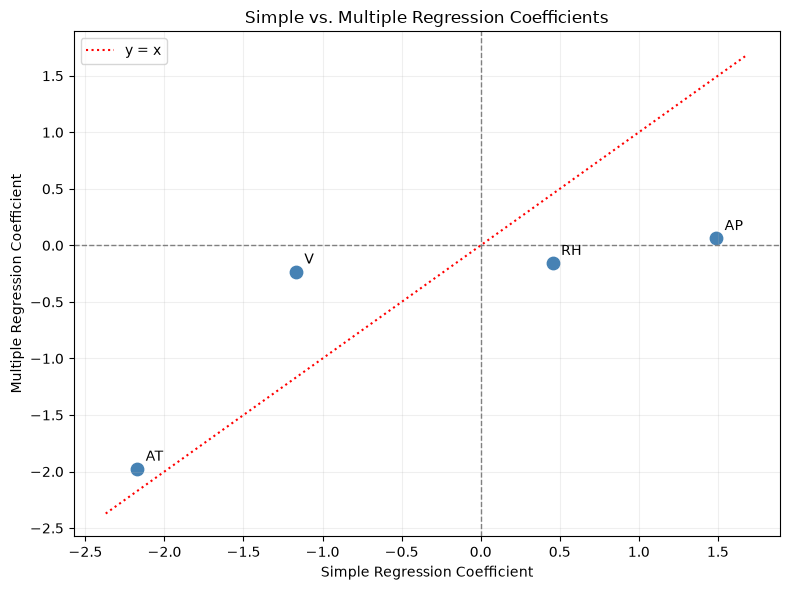

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

x = coefficient_comparison["Simple Regression"]
y = coefficient_comparison["Multiple Regression"]

ax.scatter(x, y, color="steelblue", s=80)

# Label each point
for predictor in coefficient_comparison.index:
    ax.annotate(
        predictor,
        (x.loc[predictor], y.loc[predictor]),
        xytext=(6, 6),
        textcoords="offset points"
    )

# Reference lines
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)

# y = x reference line
minimum = min(x.min(), y.min()) - 0.2
maximum = max(x.max(), y.max()) + 0.2

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle=":",
    label="y = x"
)

ax.set_xlabel("Simple Regression Coefficient")
ax.set_ylabel("Multiple Regression Coefficient")
ax.set_title("Simple vs. Multiple Regression Coefficients")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

**Answer:**

* Average Temperature (AT) had the smallest absolute change, moving from −2.17 in the simple regression to −1.98 in the multiple regression, a difference of approximately 0.19. Its association with PE remained negative.
* Exhaust Vacuum (V) changed from −1.17 to −0.23, becoming substantially less negative after controlling for the other predictors.
* Ambient Pressure (AP) had the largest absolute change, decreasing from 1.49 to 0.06, a difference of approximately 1.43. However, its association with PE remained positive.
* Relative Humidity (RH) changed direction, moving from 0.46 in the simple regression to −0.16 in the multiple regression. This is notable because it indicates that the association between RH and PE becomes negative after controlling for the other predictors.

### (f) Nonlinear Association

fitting:

$$
\begin{aligned}
PE ={}& \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon
\end{aligned}
$$

In [12]:
cubic_results = []

for variable in independent_variables:

    cubic_model = smf.ols(
        formula=f"PE ~ {variable} + I({variable}**2) + I({variable}**3)",
        data=df
    ).fit()

    cubic_results.append({
        "Predictor": variable,
        "Intercept": cubic_model.params.iloc[0],
        "Linear Coefficient": cubic_model.params.iloc[1],
        "Linear p-value": cubic_model.pvalues.iloc[1],
        "Quadratic Coefficient": cubic_model.params.iloc[2],
        "Quadratic p-value": cubic_model.pvalues.iloc[2],
        "Cubic Coefficient": cubic_model.params.iloc[3],
        "Cubic p-value": cubic_model.pvalues.iloc[3],
        "R-squared": cubic_model.rsquared,
        "Adjusted R-squared": cubic_model.rsquared_adj
    })

cubic_results_df = pd.DataFrame(cubic_results)

cubic_results_df

/var/folders/99/1qj1dgqd203_48mh9c9ts3sh0000gn/T/ipykernel_71269/2327617472.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()


,Predictor,Intercept,Linear Coefficient,Linear p-value,Quadratic Coefficient,Quadratic p-value,Cubic Coefficient,Cubic p-value,R-squared,Adjusted R-squared
0,AT,492.728143,-0.610346,7.898147e-07,-0.125138,8.833045e-73,0.002675,3.652185e-110,0.911883,0.911855
1,V,554.146849,-2.144377,2.526589e-05,-0.002712,7.684969e-01,0.000134,1.373489e-02,0.775022,0.774951
2,AP,0.074694,25.255593,4.502735e-17,-0.049952,3.666705e-17,0.000025,8.264146e-18,0.274863,0.274712
3,RH,468.413536,-1.729211,3.772510e-04,0.032145,9.395430e-06,-0.000152,1.440279e-05,0.153743,0.153477


**Answer:**

* For AT, AP, and RH, both the quadratic and cubic terms are statistically significant ($p<0.001$).
* For V, the quadratic term is not significant ($p=0.768$), but the cubic term is significant ($p=0.014$).
* Compared with the simple linear regression models, all polynomial models have higher $R^2$ values. The largest increase is 0.0185 for Exhaust Vacuum (V).

Therefore, at the $\alpha=0.05$ significance level, all four predictors show evidence of nonlinear associations with PE.


### (g) Interactions of Predictors

***AI Notes***

I used AI to help answer the question and how to set this up in the statsmodels package. I had a bit of an understanding of what they mean, but how to set it up is what I needed help with.

The prompt I used was "I'm being asked to run a full linear regression model with all pairwise interaction terms and state whether any interaction terms are statistically significant. We're using statsmodels. Can you explain what this means and how to set it up for my homework?"

The result of the query explains that we should have 6 pairwise interactions between the 4 predictors, where the full model looks like the following:
$$
\begin{aligned}
PE ={}& \beta_0 + \beta_1 AT + \beta_2 V + \beta_3 AP + \beta_4 RH \\
&+ \beta_5(AT \times V) + \beta_6(AT \times AP) + \beta_7(AT \times RH) \\
&+ \beta_8(V \times AP) + \beta_9(V \times RH) + \beta_{10}(AP \times RH) + \epsilon
\end{aligned}
$$

ChatGPT also explains that we need to include every 2-way interaction. The following code was set up using the starter code from ChatGPT.

In [13]:
interaction_model = smf.ols(
    formula='PE ~ (AT + V + AP + RH)**2',
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:59:13   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [14]:
interaction_results = pd.DataFrame({
    'Coefficient': interaction_model.params,
    'p-value': interaction_model.pvalues
})

interaction_results = interaction_results[
    interaction_results.index.str.contains(':')
]

interaction_results

,Coefficient,p-value
AT:V,0.020971,3.333358e-117
AT:AP,0.001759,4.520509e-01
AT:RH,-0.005230,1.216944e-10
V:AP,0.006812,2.877026e-07
V:RH,0.000839,8.619366e-02
AP:RH,-0.001612,3.360557e-02


**Answer:**

* Four of the six pairwise interaction terms were statistically significant at the $(\alpha=0.05)$ level: AT:V, AT:RH, V:AP, and AP:RH. For each of these terms, we reject the null hypothesis that $\beta_j=0$. This provides evidence that the effect of one predictor on PE depends on the value of the other predictor.
* The AT:AP and V:RH interactions had p-values of \(0.452\) and \(0.086\), respectively. Because both p-values exceed \(0.05\), we fail to reject the null hypothesis for these terms. Thus, there is insufficient evidence that either interaction is associated with energy output.

### (h) Improvement

#### 1. create the 70/30 split

In [15]:
train_data, test_data = train_test_split(
    df,
    test_size=0.30,
    random_state=56
)

#### 2. fit ordinary regression model

In [16]:
linear_model = smf.ols(
    formula='PE ~ AT + V + AP + RH',
    data=train_data
).fit()

print(linear_model.summary())

train_predictions = linear_model.predict(train_data)
test_predictions = linear_model.predict(test_data)

linear_train_mse = mse(
    train_data['PE'],
    train_predictions
)

linear_test_mse = mse(
    test_data['PE'],
    test_predictions
)

print("Training MSE:", linear_train_mse)
print("Testing MSE:", linear_test_mse)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                 2.161e+04
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:59:13   Log-Likelihood:                -19673.
No. Observations:                6697   AIC:                         3.936e+04
Df Residuals:                    6692   BIC:                         3.939e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    449.4418     11.759     38.222      0.0

#### 3. fit nonlinear + interaction model

In [17]:
full_formula = '''
PE ~ (AT + V + AP + RH)**2
   + I(AT**2)
   + I(V**2)
   + I(AP**2)
   + I(RH**2)
'''

full_model = smf.ols(
    formula=full_formula,
    data=train_data
).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     7132.
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:59:13   Log-Likelihood:                -19217.
No. Observations:                6697   AIC:                         3.846e+04
Df Residuals:                    6682   BIC:                         3.857e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7591.4233   1489.951     -5.095      0.0

#### 4. remove insignificant variables from p-values

**Notes:**
* the following predictors produced high p-values and are insignificant to predicting the outcome variable of Energy Output:
    * AT ($p=0.097$)
    * V ($p=0.057$)
    * AT:AP ($p=0.351$)
    * V:AP ($p=0.093$)
    * V:RH ($p=0.632$)
    * I(V ** 2) ($p=0.211$)

* Although AT and V are not individually significant, they must remain in the model because they are components of significant interactions and/or quadratic terms.

Next, I will first remove V:RH since it has the largest p-value and refit the model.

In [18]:
reduced_formula = '''
PE ~ AT + V + AP + RH
   + AT:V
   + AT:AP
   + AT:RH
   + V:AP
   + AP:RH
   + I(AT**2)
   + I(V**2)
   + I(AP**2)
   + I(RH**2)
'''

reduced_model = smf.ols(
    formula=reduced_formula,
    data=train_data
).fit()

print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     7682.
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:59:13   Log-Likelihood:                -19218.
No. Observations:                6697   AIC:                         3.846e+04
Df Residuals:                    6683   BIC:                         3.856e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7556.5143   1488.084     -5.078      0.0

**Answer:**
* After removing V:RH, the p-values for AT and AT:AP decreased, indicating stronger evidence of association. 
* In contrast, the p-values for V, V:AP, and \(V^2\) increased, indicating weaker evidence of association. However, the significant AT:V interaction became stronger. 
* These changes demonstrate why the model must be refitted and its p-values reevaluated after the next highest term, AT:AP, gets removed.

In [19]:
reduced_formula = '''
PE ~ AT + V + AP + RH
   + AT:V
   + AT:RH
   + V:AP
   + AP:RH
   + I(AT**2)
   + I(V**2)
   + I(AP**2)
   + I(RH**2)
'''

reduced_model = smf.ols(
    formula=reduced_formula,
    data=train_data
).fit()

print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     8321.
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:59:13   Log-Likelihood:                -19218.
No. Observations:                6697   AIC:                         3.846e+04
Df Residuals:                    6684   BIC:                         3.855e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8302.3956   1311.162     -6.332      0.0

**Answer:**
* After removing AT:AP, the p-values all of the predictors produced significant p-values < 0.05 except for $V^2$ which despite alightly decresasing still has a p-value of 0.215. 
* I will try removing $V^2$ and refitting the model

In [20]:
reduced_formula = '''
PE ~ AT + V + AP + RH
   + AT:V
   + AT:RH
   + V:AP
   + AP:RH
   + I(AT**2)
   + I(AP**2)
   + I(RH**2)
'''

reduced_model = smf.ols(
    formula=reduced_formula,
    data=train_data
).fit()

print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     9077.
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:59:13   Log-Likelihood:                -19219.
No. Observations:                6697   AIC:                         3.846e+04
Df Residuals:                    6685   BIC:                         3.854e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8410.2092   1308.325     -6.428      0.0

**Answer:**
* After removing $V^2$$, the p-values all of the predictors produced significant p-values < 0.05 
the following model is the final reduced model:
$$
\begin{aligned}
\widehat{PE} ={}&
-8410.2092
-2.6277(AT)
-4.5436(V)
+17.3440(AP)
+5.0409(RH) \\
&+0.0088(AT \times V)
-0.0051(AT \times RH)
+0.0040(V \times AP) \\
&-0.0047(AP \times RH)
+0.0192(AT^2)
-0.0084(AP^2)
-0.0020(RH^2)
\end{aligned}
$$

#### 5. calculate MSEs and present comparisons

In [21]:
reduced_train_predictions = reduced_model.predict(train_data)
reduced_test_predictions = reduced_model.predict(test_data)

reduced_train_mse = mse(
    train_data['PE'],
    reduced_train_predictions
)

reduced_test_mse = mse(
    test_data['PE'],
    reduced_test_predictions
)

print("Reduced model train MSE:", reduced_train_mse)
print("Reduced model test MSE:", reduced_test_mse)

Reduced model train MSE: 18.20473829092685
Reduced model test MSE: 17.930925550834452


In [22]:
mse_results = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'Reduced Interaction/Quadratic Model'
    ],
    'Train MSE': [
        linear_train_mse,
        reduced_train_mse
    ],
    'Test MSE': [
        linear_test_mse,
        reduced_test_mse
    ]
})

mse_results

,Model,Train MSE,Test MSE
0,Multiple Linear Regression,20.847194,20.600566
1,Reduced Interaction/Quadratic Model,18.204738,17.930926


**Answer:**

The multiple linear regression model had a training MSE of 20.85 and a test MSE of 20.60. After considering all pairwise interactions and quadratic terms and removing insignificant terms while preserving model hierarchy, the improved model had a training MSE of 18.20 and a test MSE of 17.93. 

Because the improved model had a lower test MSE, it provided better predictive performance on unseen data.

### (i) KNN

#### 1. prepare data

In [23]:
X_train = train_data[independent_variables]
y_train = train_data['PE']

X_test = test_data[independent_variables]
y_test = test_data['PE']

#### 2. run knn regressor

In [24]:
k_values = np.arange(1, 101)

raw_train_mse = []
raw_test_mse = []

for k in k_values:
    raw_knn = KNeighborsRegressor(n_neighbors=k)

    raw_knn.fit(X_train, y_train)

    raw_train_predictions = raw_knn.predict(X_train)
    raw_test_predictions = raw_knn.predict(X_test)

    raw_train_mse.append(
        mean_squared_error(y_train, raw_train_predictions)
    )

    raw_test_mse.append(
        mean_squared_error(y_test, raw_test_predictions)
    )

#### 3. find best k

In [25]:
best_raw_index = np.argmin(raw_test_mse)
best_raw_k = k_values[best_raw_index]

print("Best k for raw features:", best_raw_k)
print("Raw training MSE:", raw_train_mse[best_raw_index])
print("Raw testing MSE:", raw_test_mse[best_raw_index])

Best k for raw features: 6
Raw training MSE: 11.230283129261858
Raw testing MSE: 16.519084998451945


#### 4. normalize

In [26]:
scaler = StandardScaler()

X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

#### 5. run knn regressor on normalized features

In [27]:
normalized_train_mse = []
normalized_test_mse = []

for k in k_values:
    normalized_knn = KNeighborsRegressor(n_neighbors=k)

    normalized_knn.fit(X_train_normalized, y_train)

    normalized_train_predictions = normalized_knn.predict(
        X_train_normalized
    )

    normalized_test_predictions = normalized_knn.predict(
        X_test_normalized
    )

    normalized_train_mse.append(
        mean_squared_error(y_train, normalized_train_predictions)
    )

    normalized_test_mse.append(
        mean_squared_error(y_test, normalized_test_predictions)
    )

#### 6 . find best normalized k

In [28]:
best_normalized_index = np.argmin(normalized_test_mse)
best_normalized_k = k_values[best_normalized_index]

print("Best k for normalized features:", best_normalized_k)
print(
    "Normalized training MSE:",
    normalized_train_mse[best_normalized_index]
)
print(
    "Normalized testing MSE:",
    normalized_test_mse[best_normalized_index]
)

Best k for normalized features: 5
Normalized training MSE: 9.462075923547859
Normalized testing MSE: 15.092043719958202


#### 7. plot error against 1/k

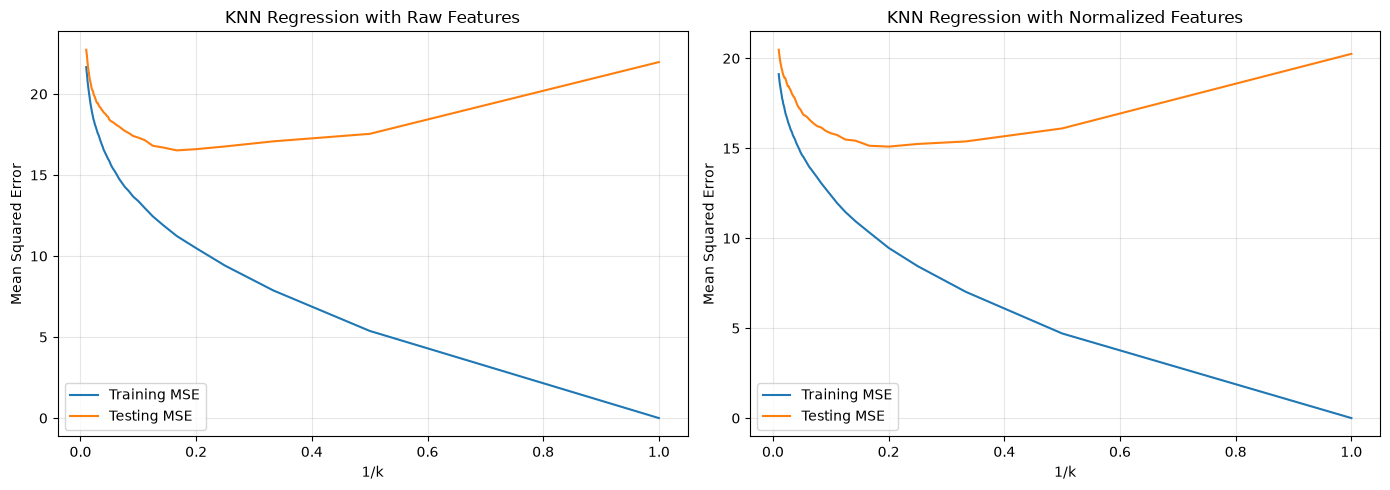

In [29]:
inverse_k = 1 / k_values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw features
axes[0].plot(
    inverse_k,
    raw_train_mse,
    label='Training MSE'
)

axes[0].plot(
    inverse_k,
    raw_test_mse,
    label='Testing MSE'
)

axes[0].set_title('KNN Regression with Raw Features')
axes[0].set_xlabel('1/k')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Normalized features
axes[1].plot(
    inverse_k,
    normalized_train_mse,
    label='Training MSE'
)

axes[1].plot(
    inverse_k,
    normalized_test_mse,
    label='Testing MSE'
)

axes[1].set_title('KNN Regression with Normalized Features')
axes[1].set_xlabel('1/k')
axes[1].set_ylabel('Mean Squared Error')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Answer:**

* For the raw predictors, the lowest test MSE was 16.52, obtained with $k=6$.
* For the normalized predictors, the lowest test MSE was 15.09, obtained with $k=5$. Standardizing the predictors prevents variables with larger numerical scales from dominating the distance, thus helping with KNN's accuracy.
* Therefore, the normalized KNN model provided better test-set performance.

### (j ) Compare KNN and Linear

In [30]:
comparison = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'Reduced Interaction/Quadratic Regression',
        f'Raw KNN (k={best_raw_k})',
        f'Normalized KNN (k={best_normalized_k})'
    ],
    'Train MSE': [
        linear_train_mse,
        reduced_train_mse,
        raw_train_mse[best_raw_index],
        normalized_train_mse[best_normalized_index]
    ],
    'Test MSE': [
        linear_test_mse,
        reduced_test_mse,
        raw_test_mse[best_raw_index],
        normalized_test_mse[best_normalized_index]
    ]
})

comparison.sort_values('Test MSE')

,Model,Train MSE,Test MSE
3,Normalized KNN (k=5),9.462076,15.092044
2,Raw KNN (k=6),11.230283,16.519085
1,Reduced Interaction/Quadratic Regression,18.204738,17.930926
0,Multiple Linear Regression,20.847194,20.600566


**Answer:**

* The linear regression model with the smallest test error was the reduced interaction model, which had a training MSE of **18.20** and a test MSE of **17.93**.
* For KNN regression, the best-performing model used normalized features with $k=5$. It had a training MSE of **9.46** and a test MSE of **15.09**.

Overall, the **normalized-feature KNN regression model** performed best because it produced the lowest test MSE, which resulted in the lowest test MSE on this particular train-test split.

## 2. ISLR: 2.4.1

### For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.

#### (a) The sample size n is extremely large, and the number of predictors p is small.

**Answer:** *Better*

When $n$ is extremely large and $p$ is small, a flexible method will generally perform better. The large number of observations provides enough information to estimate a complex relationship while reducing the risk of overfitting.

#### (b) The number of predictors p is extremely large, and the number of observations n is small.

**Answer:** *Worse*

When $n$ is small and $p$ is extremely large, a flexible method will generally perform worse. With many predictors and few observations, it may overfit to the training data, resulting in high variance and poor test performance.

#### (c) The relationship between the predictors and response is highly non-linear.

**Answer:** *Better*

When the relationship between the predictors and response is highly nonlinear, a flexible method will generally perform better because it can capture complex patterns. An inflexible method may be too limited and biased.

#### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

**Answer:** *Worse*

When the variance of the error terms is extremely high, a flexible method will generally perform worse. It may fit the random noise in the training data instead of the true relationship, leading to overfitting and high test error.

## 3. ISLR: 2.4.7

![2.4.7 Question](../data/247table.png)

#### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [31]:
x1 = [0,2,0,0,-1,1]
x2 = [3,0,1,1,0,1]
x3 = [0,0,3,2,1,1]
Y = ['Red','Red','Red','Green','Green','Red']

**Notes:**

For the test point (0,0,0), the Euclidean distance is calculated as

$$
d = \sqrt{(X_1-0)^2 + (X_2-0)^2 + (X_3-0)^2}.
$$

In [32]:
distances = []

for i in range(6):
    distance = np.sqrt(x1[i]**2 + x2[i]**2 + x3[i]**2).round(2)
    distances.append(distance)

distance_df = pd.DataFrame({
    'Observation': range(1, 7),
    'Euclidean Distance': distances,
    'Y': Y
})

distance_df

,Observation,Euclidean Distance,Y
0,1,3.00,Red
1,2,2.00,Red
2,3,3.16,Red
3,4,2.24,Green
4,5,1.41,Green
5,6,1.73,Red


**Answer:** The observation with the shortest distance is #5 with a distance of approximately 1.41

#### (b) What is our prediction with K = 1? Why?

**Answer:** *Green*

For the observation at (0,0,0), for K=1 we look at the single closest observation, which is number 5. For that observation, the outcome variable is Green, therefore **our prediction with K=1 is** ***Green***

#### (c) What is our prediction with K = 3? Why?

**Answer:** *Red*

For the observation at (0,0,0), for K=3 we look at the three closest observations, which are 5, 6 and 2. For these observations, the outcome variables are Green, Red and Red, therefore, due to having the majority **our prediction with K=3 is** ***Red***

#### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

**Answer:** *Small*

A small $K$ produces a more flexible decision boundary, allowing KNN to capture a highly nonlinear relationship. Whereas a large $K$ averages over more observations and produces a smoother, less flexible decision boundary.